In [5]:
from pathlib import Path
import os

repo_root = Path("/Users/promacraetymodis/Research/BCI-DoC-lab-simulation")
os.chdir(repo_root)

print("Working directory:", Path.cwd())

Working directory: /Users/promacraetymodis/Research/BCI-DoC-lab-simulation


# Level 1: Clinical and EEG-Style Table Basics for DoC-BCI

## Goal

This notebook simulates a small disorders of consciousness dataset and practices the basic Python workflow needed for DoC-BCI research.

## Concepts

- DoC: disorders of consciousness
- UWS: unresponsive wakefulness syndrome
- MCS: minimally conscious state
- EMCS: emergence from minimally conscious state
- CRS-R: Coma Recovery Scale-Revised
- EEG band power features
- pandas table processing
- basic plotting
- simple machine learning classification

## Engineering Goal

Create a reproducible simulated patient table that can later be reused for EEG classification and BCI training demos.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

np.random.seed(42)

results_dir = Path("results")
figures_dir = Path("figures")
data_dir = Path("data")

results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)
data_dir.mkdir(exist_ok=True)

In [9]:
n_patients = 60

diagnoses = np.random.choice(
    ["UWS", "MCS", "EMCS"],
    size=n_patients,
    p=[0.35, 0.50, 0.15]
)

patient_ids = [f"P{str(i+1).zfill(3)}" for i in range(n_patients)]

ages = np.random.randint(18, 75, size=n_patients)

etiologies = np.random.choice(
    ["TBI", "anoxic", "stroke", "other"],
    size=n_patients,
    p=[0.35, 0.30, 0.25, 0.10]
)

days_since_injury = np.random.randint(30, 720, size=n_patients)

crs_r_scores = []

for diagnosis in diagnoses:
    if diagnosis == "UWS":
        score = np.random.randint(3, 9)
    elif diagnosis == "MCS":
        score = np.random.randint(8, 18)
    else:
        score = np.random.randint(18, 24)
    crs_r_scores.append(score)

df = pd.DataFrame({
    "patient_id": patient_ids,
    "diagnosis": diagnoses,
    "age": ages,
    "etiology": etiologies,
    "days_since_injury": days_since_injury,
    "crs_r_total": crs_r_scores,
})

df.head()

,patient_id,diagnosis,age,etiology,days_since_injury,crs_r_total
0,P001,MCS,33,TBI,701,15
1,P002,EMCS,62,TBI,445,21
2,P003,MCS,35,TBI,276,8
3,P004,MCS,64,stroke,468,15
4,P005,UWS,70,TBI,232,6


In [10]:
delta_power = []
theta_power = []
alpha_power = []
beta_power = []
gamma_power = []

for diagnosis in df["diagnosis"]:
    if diagnosis == "UWS":
        delta_power.append(np.random.normal(0.40, 0.06))
        theta_power.append(np.random.normal(0.25, 0.04))
        alpha_power.append(np.random.normal(0.15, 0.03))
        beta_power.append(np.random.normal(0.12, 0.03))
        gamma_power.append(np.random.normal(0.08, 0.02))
    elif diagnosis == "MCS":
        delta_power.append(np.random.normal(0.30, 0.05))
        theta_power.append(np.random.normal(0.22, 0.04))
        alpha_power.append(np.random.normal(0.20, 0.04))
        beta_power.append(np.random.normal(0.18, 0.03))
        gamma_power.append(np.random.normal(0.10, 0.02))
    else:
        delta_power.append(np.random.normal(0.22, 0.04))
        theta_power.append(np.random.normal(0.18, 0.03))
        alpha_power.append(np.random.normal(0.25, 0.04))
        beta_power.append(np.random.normal(0.22, 0.03))
        gamma_power.append(np.random.normal(0.13, 0.02))

df["delta_power"] = np.clip(delta_power, 0, 1)
df["theta_power"] = np.clip(theta_power, 0, 1)
df["alpha_power"] = np.clip(alpha_power, 0, 1)
df["beta_power"] = np.clip(beta_power, 0, 1)
df["gamma_power"] = np.clip(gamma_power, 0, 1)

df["attention_index"] = df["beta_power"] / df["alpha_power"]

df.head()

,patient_id,diagnosis,age,etiology,days_since_injury,crs_r_total,delta_power,theta_power,alpha_power,beta_power,gamma_power,attention_index
0,P001,MCS,33,TBI,701,15,0.293793,0.249614,0.181902,0.203311,0.120911,1.117701
1,P002,EMCS,62,TBI,445,21,0.206314,0.152219,0.229481,0.241303,0.131850,1.051516
2,P003,MCS,35,TBI,276,8,0.331504,0.290517,0.209238,0.155732,0.121148,0.744281
3,P004,MCS,64,stroke,468,15,0.302568,0.254898,0.242648,0.151230,0.127640,0.623248
4,P005,UWS,70,TBI,232,6,0.454307,0.225844,0.159133,0.127716,0.080479,0.802573


In [11]:
output_csv = data_dir / "level1_simulated_doc_eeg_table.csv"
df.to_csv(output_csv, index=False)

print(f"Saved simulated dataset to: {output_csv}")
df.head()

Saved simulated dataset to: data/level1_simulated_doc_eeg_table.csv


,patient_id,diagnosis,age,etiology,days_since_injury,crs_r_total,delta_power,theta_power,alpha_power,beta_power,gamma_power,attention_index
0,P001,MCS,33,TBI,701,15,0.293793,0.249614,0.181902,0.203311,0.120911,1.117701
1,P002,EMCS,62,TBI,445,21,0.206314,0.152219,0.229481,0.241303,0.131850,1.051516
2,P003,MCS,35,TBI,276,8,0.331504,0.290517,0.209238,0.155732,0.121148,0.744281
3,P004,MCS,64,stroke,468,15,0.302568,0.254898,0.242648,0.151230,0.127640,0.623248
4,P005,UWS,70,TBI,232,6,0.454307,0.225844,0.159133,0.127716,0.080479,0.802573


In [12]:
df.groupby("diagnosis")[["age", "days_since_injury", "crs_r_total"]].describe()

age                                                        \
          count       mean        std   min    25%   50%    75%   max   
diagnosis                                                               
EMCS       10.0  43.500000  11.909380  24.0  34.25  43.5  52.00  62.0   
MCS        24.0  46.458333  16.465984  18.0  33.75  50.5  59.75  72.0   
UWS        26.0  40.346154  15.947269  18.0  25.25  41.5  53.50  70.0   

          days_since_injury              ...                crs_r_total  \
                      count        mean  ...     75%    max       count   
diagnosis                                ...                              
EMCS                   10.0  367.900000  ...  441.25  688.0        10.0   
MCS                    24.0  371.291667  ...  523.50  701.0        24.0   
UWS                    26.0  365.653846  ...  623.50  702.0        26.0   

                                                               
                mean       std   min    25%   50%   75%   max  
diagnosis                                                      
EMCS       21.400000  2.011080  18.0  21.00  22.0  23.0  23.0  
MCS        11.041667  2.758058   8.0   8.75  10.0  13.0  16.0  
UWS         5.923077  1.647376   3.0   5.00   6.0   7.0   8.0  

[3 rows x 24 columns]

In [13]:
df["diagnosis"].value_counts()

diagnosis
UWS     26
MCS     24
EMCS    10
Name: count, dtype: int64

In [14]:
pd.crosstab(df["diagnosis"], df["etiology"])

etiology,TBI,anoxic,other,stroke
diagnosis,,,,
EMCS,6,2,1,1
MCS,11,6,1,6
UWS,10,11,2,3


/var/folders/wx/pf7xs6dd4lq65vyh1vf_771h0000gn/T/ipykernel_43904/4289956672.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=diagnosis_order)


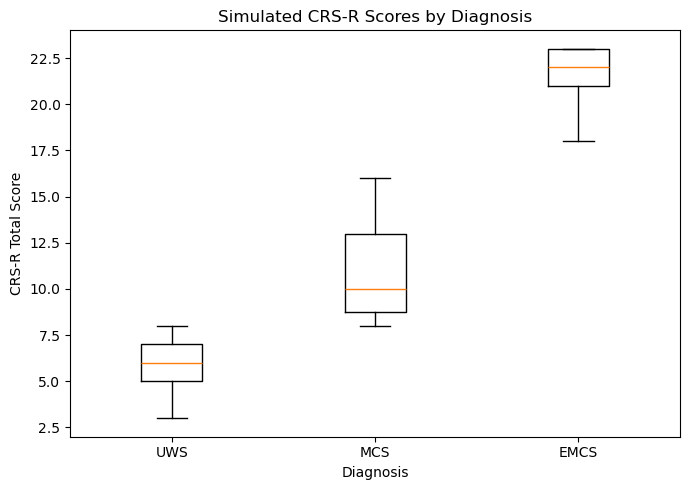

Saved figure to: figures/level1_crsr_by_diagnosis.png


In [15]:
plt.figure(figsize=(7, 5))

diagnosis_order = ["UWS", "MCS", "EMCS"]
data_to_plot = [df[df["diagnosis"] == d]["crs_r_total"] for d in diagnosis_order]

plt.boxplot(data_to_plot, labels=diagnosis_order)
plt.xlabel("Diagnosis")
plt.ylabel("CRS-R Total Score")
plt.title("Simulated CRS-R Scores by Diagnosis")
plt.tight_layout()

figure_path = figures_dir / "level1_crsr_by_diagnosis.png"
plt.savefig(figure_path, dpi=300)

plt.show()

print(f"Saved figure to: {figure_path}")

In [16]:
band_columns = [
    "delta_power",
    "theta_power",
    "alpha_power",
    "beta_power",
    "gamma_power",
]

band_means = df.groupby("diagnosis")[band_columns].mean()
band_means

,delta_power,theta_power,alpha_power,beta_power,gamma_power
diagnosis,,,,,
EMCS,0.199580,0.177333,0.237636,0.217157,0.139055
MCS,0.307228,0.236701,0.198047,0.189110,0.104739
UWS,0.415844,0.256216,0.143051,0.121562,0.082697


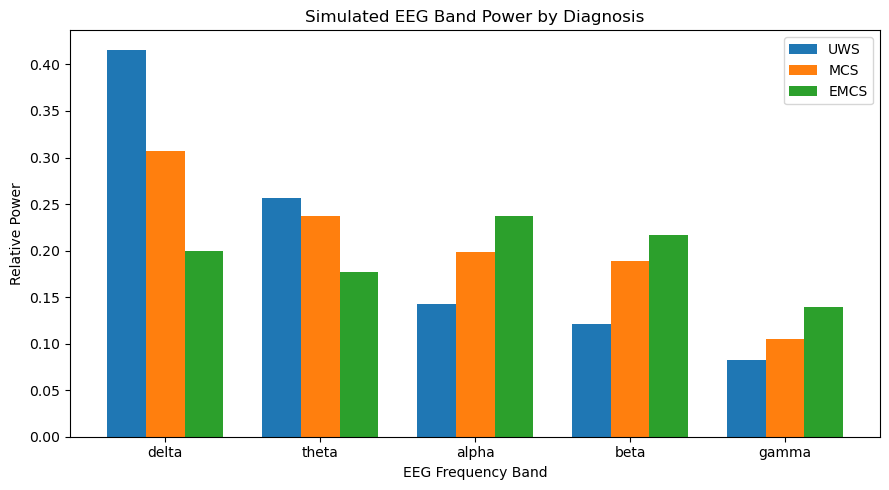

Saved figure to: figures/level1_eeg_bandpower_by_diagnosis.png


In [17]:
plt.figure(figsize=(9, 5))

x = np.arange(len(band_columns))
width = 0.25

for i, diagnosis in enumerate(diagnosis_order):
    values = band_means.loc[diagnosis].values
    plt.bar(x + i * width, values, width=width, label=diagnosis)

plt.xticks(x + width, ["delta", "theta", "alpha", "beta", "gamma"])
plt.xlabel("EEG Frequency Band")
plt.ylabel("Relative Power")
plt.title("Simulated EEG Band Power by Diagnosis")
plt.legend()
plt.tight_layout()

figure_path = figures_dir / "level1_eeg_bandpower_by_diagnosis.png"
plt.savefig(figure_path, dpi=300)

plt.show()

print(f"Saved figure to: {figure_path}")

In [ ]:
binary_df = df[df["diagnosis"].isin(["UWS", "MCS"])].copy()

feature_columns = [
    "age",
    "days_since_injury",
    "crs_r_total",
    "delta_power",
    "theta_power",
    "alpha_power",
    "beta_power",
    "gamma_power",
    "attention_index",
]

X = binary_df[feature_columns]
y = binary_df["diagnosis"].map({"UWS": 0, "MCS": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["UWS", "MCS"]))